# 1. Setup

In [1]:
# Utilities
import time
import warnings
warnings.filterwarnings("ignore")

# Dataframe
import numpy as np
import pandas as pd

# ML: Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)
from sklearn.feature_selection import mutual_info_classif
from sklearn.naive_bayes import GaussianNB

# Bayesian Network: pgmpy
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import (
    TreeSearch, HillClimbSearch,
    MaximumLikelihoodEstimator, BayesianEstimator,
    K2, BDeu
)
from pgmpy.inference import VariableElimination

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.figure_factory as ff

# Saving models
import joblib

print("Core libraries loaded.")

Core libraries loaded.


In [2]:
# Constants
RANDOM_STATE = 8
np.random.seed(RANDOM_STATE)

LONELINESS_CUTOFF = 25
TARGET = "loneliness_class"
TOP_N_FEATURES = 20
BN_BINS = 3
TEST_SIZE = 0.2

In [3]:
# Utilities
def format_time(seconds):
    hrs = int(seconds // 3600)
    mins = int((seconds % 3600) // 60)
    secs = seconds % 60
    parts = []
    if hrs: parts.append(f"{hrs}h")
    if mins: parts.append(f"{mins}m")
    parts.append(f"{secs:.2f}s")
    return " ".join(parts)

# 2. Dataset Loading & Preprocessing

In [5]:
DATA_PATH = "../../data/phase4.csv"

dataset = pd.read_csv(DATA_PATH)

# Select relevant columns
dataset = dataset[[
    'sex', 'age', 'married', 'child', 'hincome', 'pincome', 'job_group',
    'med_self', 'med_fam',
    'current_physical', 'past_physical', 'current_mental', 'past_mental',
    'current_covid19', 'past_covid19',
    'exercise', 'healthydiet', 'healthysleep', 'favoriteactivity',
    'interaction_offline', 'interaction_online',
    'pb_continuous', 'pb_altruistic', 'pb_avoidant', 'pb_understanding',
    'optimism', 'deteriorationeconomy', 'deteriorationinteract',
    'frustration', 'covidanxiety', 'covidsleepless',
    'difficultyliving', 'difficultywork',
    'k6_total', 'phq9_total', 'lsns6_total', 'sss8_total', 'shs_total',
    'ucla_total'
]]

print(f"Dataset loaded: {dataset.shape[0]} rows, {dataset.shape[1]} columns")
dataset.head()

Dataset loaded: 2659 rows, 39 columns


,sex,age,married,child,hincome,pincome,job_group,med_self,med_fam,current_physical,...,covidanxiety,covidsleepless,difficultyliving,difficultywork,k6_total,phq9_total,lsns6_total,sss8_total,shs_total,ucla_total
0,1.0,57.0,2.0,2.0,4.0,3.0,1.0,2.0,2.0,2.0,...,5.0,5.0,5.0,5.0,12.0,15.0,4.0,18.0,4.00,24.0
1,2.0,70.0,2.0,2.0,7.0,1.0,2.0,2.0,2.0,2.0,...,5.0,1.0,1.0,6.0,1.0,0.0,18.0,1.0,4.50,11.0
2,1.0,52.0,1.0,1.0,3.0,3.0,1.0,2.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,2.0,0.0,1.0,4.00,32.0
3,1.0,66.0,2.0,2.0,4.0,2.0,1.0,2.0,2.0,2.0,...,1.0,1.0,1.0,1.0,0.0,0.0,13.0,0.0,5.50,21.0
4,1.0,63.0,2.0,2.0,7.0,7.0,1.0,2.0,2.0,2.0,...,4.0,2.0,4.0,4.0,0.0,2.0,18.0,0.0,5.25,22.0


In [6]:
# Preprocessing
dataset_cleaned = dataset.copy()

# Fix hincome/pincome: replace invalid (10) and NaN with mode
for col in ['hincome', 'pincome']:
    mode_val = dataset_cleaned.loc[
        ~dataset_cleaned[col].isin([10]) & dataset_cleaned[col].notna(), col
    ].mode()[0]
    dataset_cleaned[col] = dataset_cleaned[col].replace([10, np.nan], mode_val)

# Drop rows with remaining NaN
n_before = len(dataset_cleaned)
dataset_cleaned = dataset_cleaned.dropna()
print(f"Rows after NaN removal: {len(dataset_cleaned)} (dropped {n_before - len(dataset_cleaned)})")

# Remove outliers in hincome/pincome via IQR
n_before = len(dataset_cleaned)
Q1 = dataset_cleaned[['hincome', 'pincome']].quantile(0.25)
Q3 = dataset_cleaned[['hincome', 'pincome']].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
mask = ~((dataset_cleaned[['hincome', 'pincome']] < lower) |
         (dataset_cleaned[['hincome', 'pincome']] > upper)).any(axis=1)
dataset_cleaned = dataset_cleaned[mask].reset_index(drop=True)
print(f"Rows after outlier removal: {len(dataset_cleaned)} (dropped {n_before - len(dataset_cleaned)})")

Rows after NaN removal: 2659 (dropped 0)
Rows after outlier removal: 2539 (dropped 120)


In [7]:
# Create binary loneliness target
dataset_cleaned[TARGET] = (dataset_cleaned['ucla_total'] >= LONELINESS_CUTOFF).astype(int)

label_names = {0: 'Not Lonely', 1: 'Lonely'}
print(f"UCLA score range: [{dataset_cleaned['ucla_total'].min():.0f}, {dataset_cleaned['ucla_total'].max():.0f}]")
print(f"Clinical cutoff: {LONELINESS_CUTOFF}")
print(f"Median UCLA score: {dataset_cleaned['ucla_total'].median():.1f}")
print(f"\nClass distribution:")
print(dataset_cleaned[TARGET].value_counts().sort_index().rename(index=label_names))

UCLA score range: [10, 40]
Clinical cutoff: 25
Median UCLA score: 24.0

Class distribution:
loneliness_class
Not Lonely    1345
Lonely        1194
Name: count, dtype: int64


# 3. EDA


In [8]:
# Statistical summary
dataset_cleaned.describe()

,sex,age,married,child,hincome,pincome,job_group,med_self,med_fam,current_physical,...,covidsleepless,difficultyliving,difficultywork,k6_total,phq9_total,lsns6_total,sss8_total,shs_total,ucla_total,loneliness_class
count,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,...,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000
mean,1.425364,56.033478,1.630563,1.568334,2.929894,2.038992,1.752659,1.953131,1.953525,1.933832,...,2.155967,2.202836,2.332020,3.563214,3.455297,8.886963,4.765656,4.472627,23.569909,0.470264
std,0.494496,12.850356,0.482747,0.495406,1.663771,1.361861,1.245428,0.211400,0.210553,0.248624,...,1.384400,1.430907,1.518614,5.304168,5.491869,6.224920,5.414045,1.152412,5.983769,0.499213
min,1.000000,22.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,10.000000,0.000000
25%,1.000000,47.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,4.000000,20.000000,0.000000
50%,1.000000,56.000000,2.000000,2.000000,3.000000,2.000000,1.000000,2.000000,2.000000,2.000000,...,1.000000,1.000000,2.000000,1.000000,1.000000,9.000000,3.000000,4.500000,24.000000,0.000000
75%,2.000000,65.000000,2.000000,2.000000,4.000000,3.000000,2.000000,2.000000,2.000000,2.000000,...,4.000000,4.000000,4.000000,5.000000,5.000000,13.000000,7.000000,5.250000,26.000000,1.000000
max,2.000000,92.000000,2.000000,2.000000,7.000000,6.000000,5.000000,2.000000,2.000000,2.000000,...,7.000000,7.000000,7.000000,24.000000,27.000000,30.000000,32.000000,7.000000,40.000000,1.000000


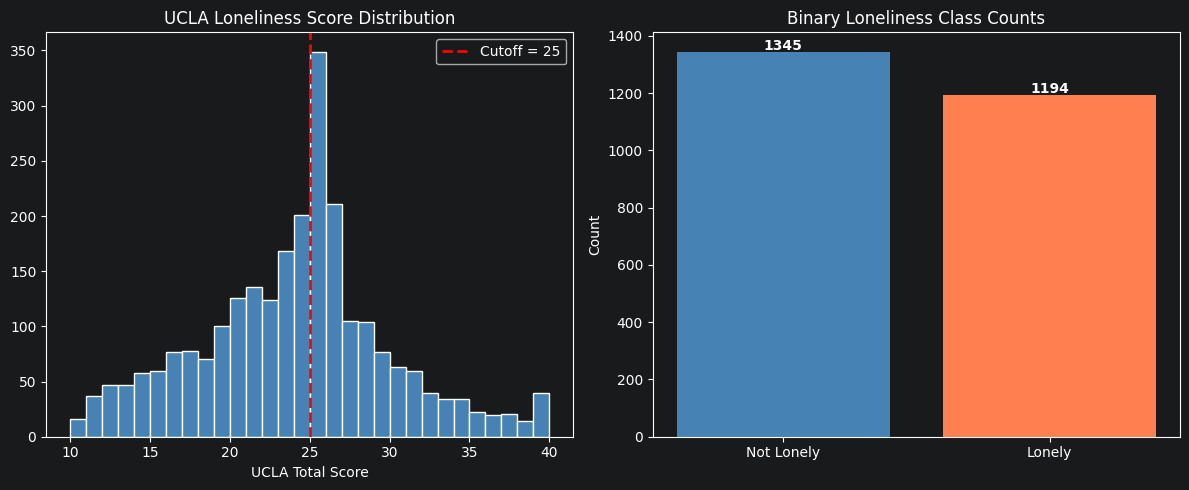

In [9]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# UCLA score distribution with cutoff
axes[0].hist(dataset_cleaned['ucla_total'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(LONELINESS_CUTOFF, color='red', linestyle='--', linewidth=2,
                label=f'Cutoff = {LONELINESS_CUTOFF}')
axes[0].set_title('UCLA Loneliness Score Distribution')
axes[0].set_xlabel('UCLA Total Score')
axes[0].legend()

# Binary class counts
counts = dataset_cleaned[TARGET].value_counts().sort_index()
axes[1].bar([label_names[i] for i in counts.index], counts.values,
            color=['steelblue', 'coral'])
axes[1].set_title('Binary Loneliness Class Counts')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

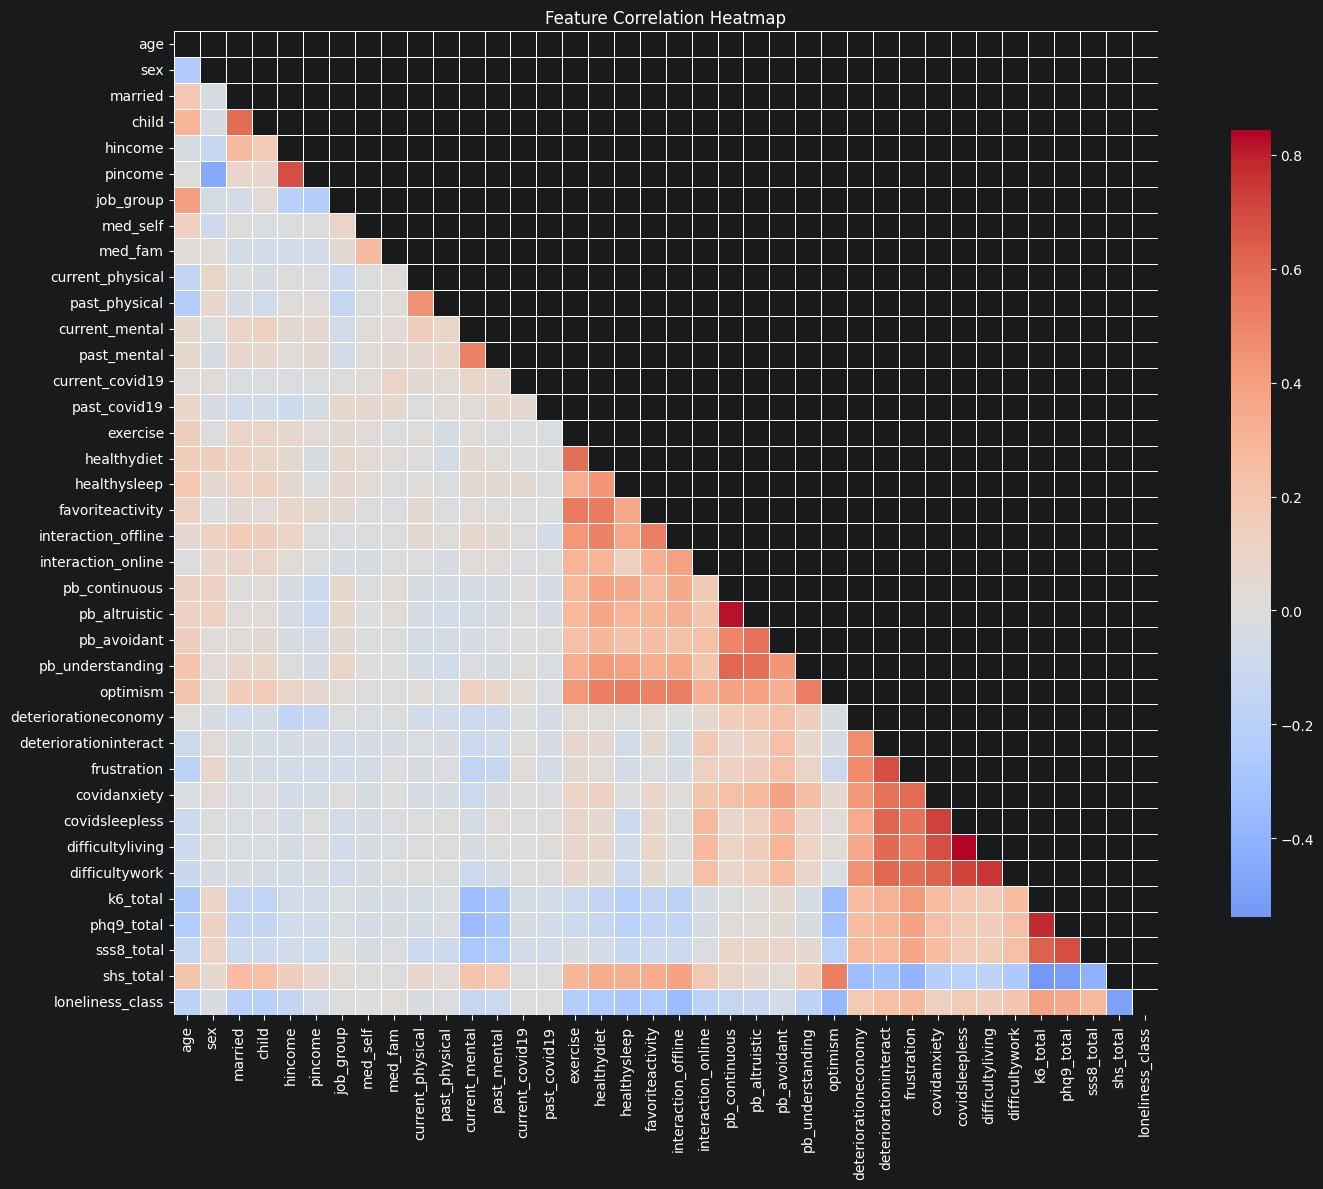

In [10]:
# Feature list (excluding target)
feature_cols = [
    'age', 'sex', 'married', 'child', 'hincome', 'pincome', 'job_group',
    'med_self', 'med_fam', 'current_physical', 'past_physical',
    'current_mental', 'past_mental', 'current_covid19', 'past_covid19',
    'exercise', 'healthydiet', 'healthysleep', 'favoriteactivity',
    'interaction_offline', 'interaction_online',
    'pb_continuous', 'pb_altruistic', 'pb_avoidant', 'pb_understanding',
    'optimism', 'deteriorationeconomy', 'deteriorationinteract',
    'frustration', 'covidanxiety', 'covidsleepless',
    'difficultyliving', 'difficultywork',
    'k6_total', 'phq9_total', 'sss8_total', 'shs_total'
]

# Correlation heatmap
plt.figure(figsize=(16, 12))
corr = dataset_cleaned[feature_cols + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

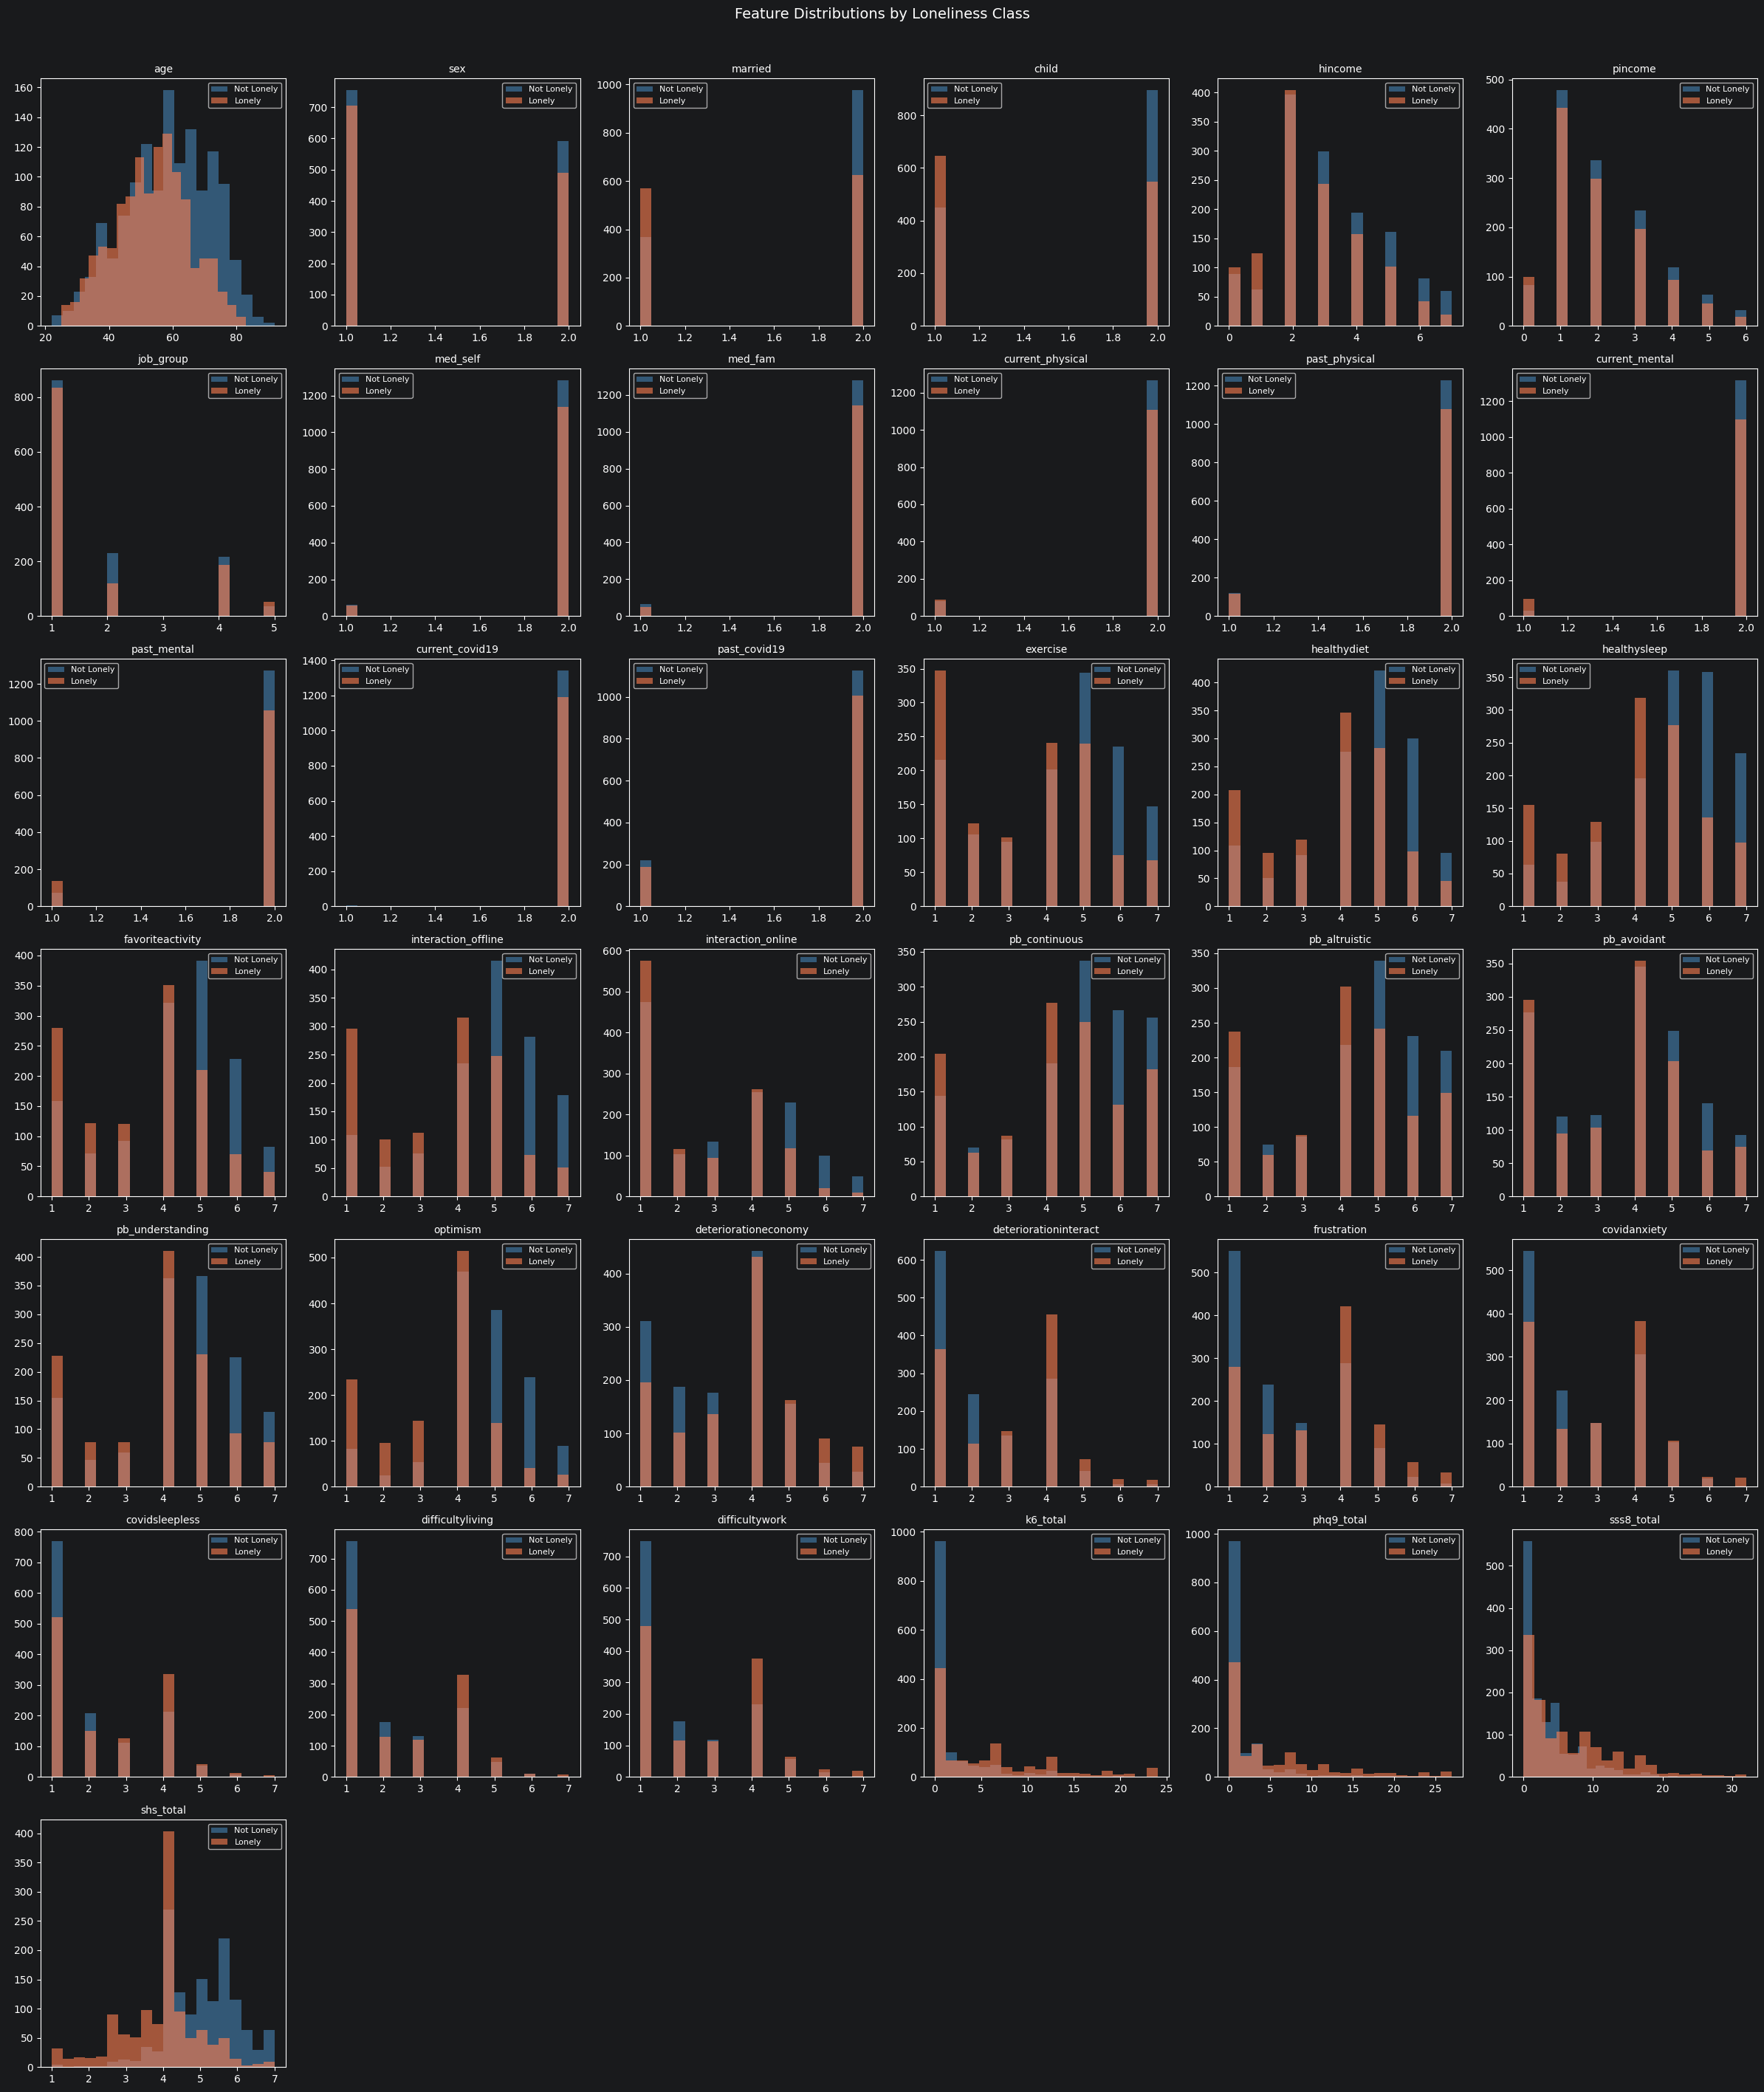

In [11]:
# Feature distributions by target class
n_cols = 6
n_rows = (len(feature_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 4 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    if i < len(axes):
        for label, color in zip([0, 1], ['steelblue', 'coral']):
            subset = dataset_cleaned[dataset_cleaned[TARGET] == label][feat]
            axes[i].hist(subset, bins=20, alpha=0.6, color=color,
                        label=label_names[label])
        axes[i].set_title(feat, fontsize=10)
        axes[i].legend(fontsize=8)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Loneliness Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 4. Train-Test Split

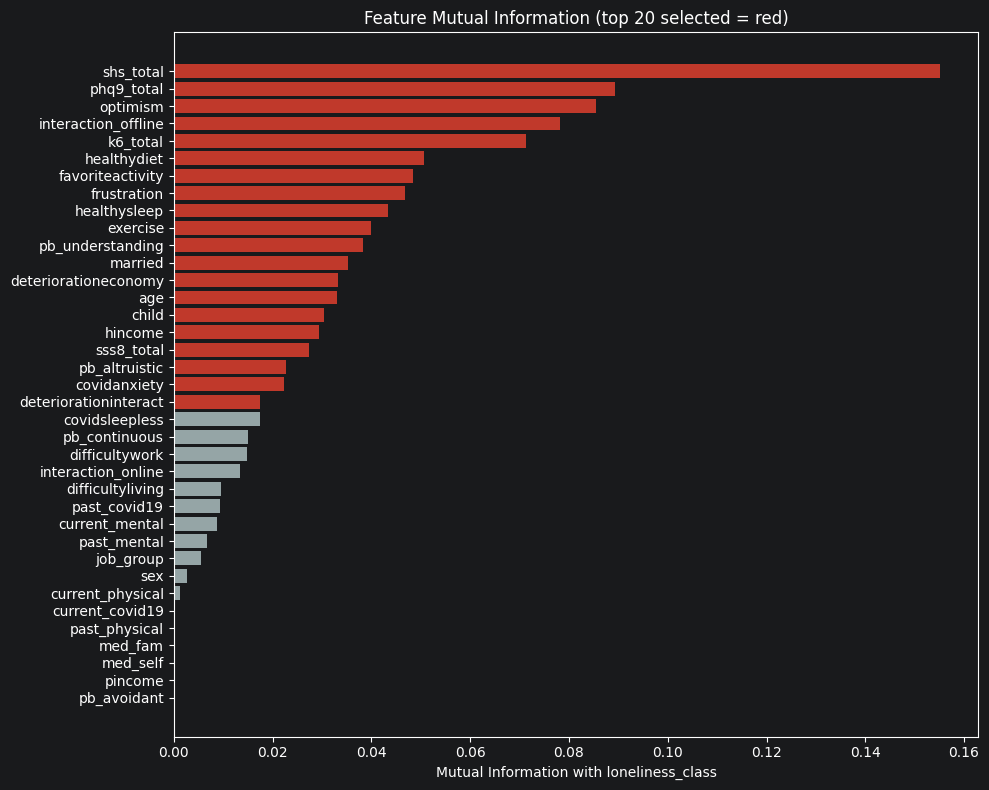


Selected features (20):
   1. shs_total                      MI = 0.1551
   2. phq9_total                     MI = 0.0893
   3. optimism                       MI = 0.0854
   4. interaction_offline            MI = 0.0781
   5. k6_total                       MI = 0.0712
   6. healthydiet                    MI = 0.0507
   7. favoriteactivity               MI = 0.0484
   8. frustration                    MI = 0.0469
   9. healthysleep                   MI = 0.0433
  10. exercise                       MI = 0.0398
  11. pb_understanding               MI = 0.0384
  12. married                        MI = 0.0353
  13. deteriorationeconomy           MI = 0.0332
  14. age                            MI = 0.0329
  15. child                          MI = 0.0305
  16. hincome                        MI = 0.0294
  17. sss8_total                     MI = 0.0274
  18. pb_altruistic                  MI = 0.0227
  19. covidanxiety                   MI = 0.0224
  20. deteriorationinteract          MI = 0.

In [12]:
# Feature selection via mutual information
X_full = dataset_cleaned[feature_cols].values
y_full = dataset_cleaned[TARGET].values

mi_scores = mutual_info_classif(X_full, y_full, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'Feature': feature_cols, 'MI': mi_scores}).sort_values('MI', ascending=False)

selected_features = mi_df['Feature'].iloc[:TOP_N_FEATURES].tolist()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#c0392b' if f in selected_features else '#95a5a6' for f in mi_df['Feature']]
ax.barh(mi_df['Feature'], mi_df['MI'], color=colors)
ax.set_xlabel('Mutual Information with loneliness_class')
ax.set_title(f'Feature Mutual Information (top {TOP_N_FEATURES} selected = red)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nSelected features ({TOP_N_FEATURES}):")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f:<30s} MI = {mi_df.loc[mi_df['Feature']==f, 'MI'].values[0]:.4f}")

In [13]:
# 80/20 train-test split
X = dataset_cleaned[selected_features]
y = dataset_cleaned[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing set:  {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"\nTraining target distribution:\n{y_train.value_counts().sort_index().rename(index=label_names)}")
print(f"\nTest target distribution:\n{y_test.value_counts().sort_index().rename(index=label_names)}")

Training set: 2031 samples, 20 features
Testing set:  508 samples, 20 features

Training target distribution:
loneliness_class
Not Lonely    1076
Lonely         955
Name: count, dtype: int64

Test target distribution:
loneliness_class
Not Lonely    269
Lonely        239
Name: count, dtype: int64


# 5. Baseline Model Training


In [14]:
def predict_bn(model, X_test_df, target_col):
    """Predict class labels and probabilities using a pgmpy BayesianNetwork."""
    y_pred = model.predict(X_test_df)[target_col].values
    y_prob_df = model.predict_probability(X_test_df)
    # predict_probability returns columns like 'target_0', 'target_1'
    prob_col_1 = f"{target_col}_1"
    if prob_col_1 in y_prob_df.columns:
        y_prob = y_prob_df[prob_col_1].values
    else:
        # Fallback: take the last column
        y_prob = y_prob_df.iloc[:, -1].values
    return y_pred, y_prob

In [15]:
# Discretize features for Bayesian Network models
df_train_bn = pd.concat([X_train, y_train], axis=1).reset_index(drop=True)
df_test_bn = pd.concat([X_test, y_test], axis=1).reset_index(drop=True)

discretizers = {}
for col in selected_features:
    n_unique = df_train_bn[col].nunique()
    if n_unique > BN_BINS:
        disc = KBinsDiscretizer(n_bins=BN_BINS, encode='ordinal', strategy='quantile')
        df_train_bn[col] = disc.fit_transform(df_train_bn[[col]]).astype(int).ravel()
        df_test_bn[col] = disc.transform(df_test_bn[[col]]).astype(int).ravel()
        discretizers[col] = disc
    else:
        le = LabelEncoder()
        df_train_bn[col] = le.fit_transform(df_train_bn[col])
        df_test_bn[col] = le.transform(df_test_bn[col])

# Ensure all columns are integer-typed for pgmpy
df_train_bn = df_train_bn.astype(int)
df_test_bn = df_test_bn.astype(int)

print("Feature value ranges after discretization:")
for col in selected_features:
    print(f"  {col:<30s}: {df_train_bn[col].nunique()} unique values")

Feature value ranges after discretization:
  shs_total                     : 3 unique values
  phq9_total                    : 2 unique values
  optimism                      : 3 unique values
  interaction_offline           : 3 unique values
  k6_total                      : 2 unique values
  healthydiet                   : 3 unique values
  favoriteactivity              : 3 unique values
  frustration                   : 3 unique values
  healthysleep                  : 3 unique values
  exercise                      : 3 unique values
  pb_understanding              : 3 unique values
  married                       : 2 unique values
  deteriorationeconomy          : 3 unique values
  age                           : 3 unique values
  child                         : 2 unique values
  hincome                       : 3 unique values
  sss8_total                    : 3 unique values
  pb_altruistic                 : 3 unique values
  covidanxiety                  : 2 unique values
  deter

In [16]:
# Build BN model structures

# --- 1. Naive Bayes BN ---
# Build as DiscreteBayesianNetwork with NB structure (target -> each feature)
nb_edges = [(TARGET, feat) for feat in selected_features]
nb_model = DiscreteBayesianNetwork(nb_edges)
nb_model.fit(df_train_bn, estimator=MaximumLikelihoodEstimator)
print("Naive Bayes BN structure built.")

# --- 2. TAN (Tree-Augmented Naive Bayes) ---
# root_node must be a feature node (not the class node)
tan_root = selected_features[0]
tan_search = TreeSearch(df_train_bn, root_node=tan_root)
tan_dag = tan_search.estimate(estimator_type="tan", class_node=TARGET)
tan_model = DiscreteBayesianNetwork(tan_dag.edges())
tan_model.fit(df_train_bn, estimator=MaximumLikelihoodEstimator)
print("TAN BN structure built.")

# --- 3. Hill Climb Search BN ---
hc_search = HillClimbSearch(df_train_bn)
hc_dag = hc_search.estimate(scoring_method=K2(df_train_bn))
hc_model = DiscreteBayesianNetwork(hc_dag.edges())
hc_model.fit(df_train_bn, estimator=MaximumLikelihoodEstimator)
print("Hill Climb BN structure built.")

# --- 4. Hill Climb BN with BDeu scoring ---
hc_search_bdeu = HillClimbSearch(df_train_bn)
hc_dag_bdeu = hc_search_bdeu.estimate(scoring_method=BDeu(df_train_bn))
hc_model_bdeu = DiscreteBayesianNetwork(hc_dag_bdeu.edges())
hc_model_bdeu.fit(df_train_bn, estimator=MaximumLikelihoodEstimator)
print("Hill Climb BN (BDeu) structure built.")

Naive Bayes BN structure built.


Building tree: 100%|██████████| 210/210.0 [00:01<00:00, 134.43it/s]


TAN BN structure built.


  0%|          | 61/1000000 [00:01<8:58:03, 30.97it/s] 


Hill Climb BN structure built.


  0%|          | 44/1000000 [00:01<9:21:24, 29.69it/s] 

Hill Climb BN (BDeu) structure built.


In [17]:
# Train and evaluate all baseline models
X_test_bn = df_test_bn[selected_features]

bn_models = [
    ("Naive Bayes BN", nb_model),
    ("TAN BN", tan_model),
    ("Hill Climb BN (K2)", hc_model),
    ("Hill Climb BN (BDeu)", hc_model_bdeu),
]

results = []
trained_models = {}
cm_data = {}

# BN models (pgmpy)
for name, model in bn_models:
    print(f"\n{'='*60}")
    print(f"  {name} (baseline)")
    print(f"{'='*60}")

    start_train = time.time()
    # Models are already fitted above
    train_time = time.time() - start_train

    start_test = time.time()
    y_pred, y_prob = predict_bn(model, X_test_bn, TARGET)
    test_time = time.time() - start_test

    acc = accuracy_score(y_test.values, y_pred)
    f1 = f1_score(y_test.values, y_pred)
    auc = roc_auc_score(y_test.values, y_prob)

    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC AUC:  {auc:.4f}")
    print(f"  Predict:  {format_time(test_time)}")
    print(f"\n{classification_report(y_test.values, y_pred, target_names=['Not Lonely', 'Lonely'])}")

    results.append({
        "Model": name, "Accuracy": acc, "F1-Score": f1,
        "ROC AUC": auc, "Train Time (s)": train_time, "Test Time (s)": test_time
    })
    trained_models[name] = model
    cm_data[name] = confusion_matrix(y_test.values, y_pred)

# Sklearn Gaussian Naive Bayes (continuous features, as comparison)
print(f"\n{'='*60}")
print(f"  Gaussian Naive Bayes — sklearn (baseline)")
print(f"{'='*60}")

gnb = GaussianNB()
start_train = time.time()
gnb.fit(X_train, y_train)
train_time = time.time() - start_train

start_test = time.time()
y_pred_gnb = gnb.predict(X_test)
y_prob_gnb = gnb.predict_proba(X_test)[:, 1]
test_time = time.time() - start_test

acc = accuracy_score(y_test, y_pred_gnb)
f1 = f1_score(y_test, y_pred_gnb)
auc = roc_auc_score(y_test, y_prob_gnb)

print(f"  Accuracy: {acc:.4f}")
print(f"  F1-Score: {f1:.4f}")
print(f"  ROC AUC:  {auc:.4f}")
print(f"  Train:    {format_time(train_time)}")
print(f"  Predict:  {format_time(test_time)}")
print(f"\n{classification_report(y_test, y_pred_gnb, target_names=['Not Lonely', 'Lonely'])}")

results.append({
    "Model": "Gaussian NB (sklearn)", "Accuracy": acc, "F1-Score": f1,
    "ROC AUC": auc, "Train Time (s)": train_time, "Test Time (s)": test_time
})
trained_models["Gaussian NB (sklearn)"] = gnb
cm_data["Gaussian NB (sklearn)"] = confusion_matrix(y_test, y_pred_gnb)

df_results = pd.DataFrame(results)
print("\n" + "="*60)
print("  All baseline models trained.")
print("="*60)


  Naive Bayes BN (baseline)


100%|██████████| 503/503 [00:01<00:00, 282.21it/s]


  Accuracy: 0.7736
  F1-Score: 0.7732
  ROC AUC:  0.8469
  Predict:  3.48s

              precision    recall  f1-score   support

  Not Lonely       0.82      0.73      0.77       269
      Lonely       0.73      0.82      0.77       239

    accuracy                           0.77       508
   macro avg       0.78      0.78      0.77       508
weighted avg       0.78      0.77      0.77       508


  TAN BN (baseline)


100%|██████████| 503/503 [00:02<00:00, 208.56it/s]


  Accuracy: 0.7677
  F1-Score: 0.7631
  ROC AUC:  0.8415
  Predict:  4.06s

              precision    recall  f1-score   support

  Not Lonely       0.80      0.74      0.77       269
      Lonely       0.73      0.79      0.76       239

    accuracy                           0.77       508
   macro avg       0.77      0.77      0.77       508
weighted avg       0.77      0.77      0.77       508


  Hill Climb BN (K2) (baseline)


100%|██████████| 503/503 [00:02<00:00, 174.36it/s]


  Accuracy: 0.7520
  F1-Score: 0.7375
  ROC AUC:  0.8151
  Predict:  4.54s

              precision    recall  f1-score   support

  Not Lonely       0.77      0.76      0.76       269
      Lonely       0.73      0.74      0.74       239

    accuracy                           0.75       508
   macro avg       0.75      0.75      0.75       508
weighted avg       0.75      0.75      0.75       508


  Hill Climb BN (BDeu) (baseline)


100%|██████████| 503/503 [00:02<00:00, 189.74it/s]


  Accuracy: 0.7657
  F1-Score: 0.7546
  ROC AUC:  0.8140
  Predict:  4.26s

              precision    recall  f1-score   support

  Not Lonely       0.79      0.77      0.78       269
      Lonely       0.74      0.77      0.75       239

    accuracy                           0.77       508
   macro avg       0.77      0.77      0.77       508
weighted avg       0.77      0.77      0.77       508


  Gaussian Naive Bayes — sklearn (baseline)
  Accuracy: 0.7638
  F1-Score: 0.7510
  ROC AUC:  0.8345
  Train:    0.00s
  Predict:  0.00s

              precision    recall  f1-score   support

  Not Lonely       0.78      0.77      0.78       269
      Lonely       0.74      0.76      0.75       239

    accuracy                           0.76       508
   macro avg       0.76      0.76      0.76       508
weighted avg       0.76      0.76      0.76       508


  All baseline models trained.


# 6. Results & Comparison

In [18]:
# Results table
display(df_results.sort_values('F1-Score', ascending=False))

,Model,Accuracy,F1-Score,ROC AUC,Train Time (s),Test Time (s)
0,Naive Bayes BN,0.773622,0.773176,0.846876,4.768372e-07,3.483626
1,TAN BN,0.767717,0.763052,0.841494,4.768372e-07,4.063392
3,Hill Climb BN (BDeu),0.765748,0.754639,0.814002,7.152557e-07,4.262056
4,Gaussian NB (sklearn),0.763780,0.751037,0.834495,1.390219e-03,0.001379
2,Hill Climb BN (K2),0.751969,0.737500,0.815083,2.384186e-07,4.538917


In [19]:
# Confusion matrices
for name in cm_data:
    cm = cm_data[name]
    fig_cm = ff.create_annotated_heatmap(
        z=cm.tolist(),
        x=['Predicted Not Lonely', 'Predicted Lonely'],
        y=['Actual Not Lonely', 'Actual Lonely'],
        annotation_text=[[str(y) for y in x] for x in cm.tolist()],
        colorscale='Viridis'
    )
    fig_cm.update_layout(title_text=f'Confusion Matrix (Baseline): {name}',
                         yaxis=dict(autorange='reversed'), height=350)
    fig_cm.show()

# 7. Save Models & Results


In [20]:
# Save all baseline models
for name, model in trained_models.items():
    safe_name = name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("-", "_")
    save_path = f"models/bn_classification_baseline_{safe_name}.joblib"
    joblib.dump(model, save_path)
    print(f"Saved: {save_path}")

# Save results
df_results.to_csv("models/bn_classification_baseline_results.csv", index=False)
print("\nBaseline comparison results saved to models/bn_classification_baseline_results.csv")

# Save discretizers
joblib.dump(discretizers, "models/bn_classification_discretizers.joblib")
print("Discretizers saved.")

Saved: models/bn_classification_baseline_naive_bayes_bn.joblib
Saved: models/bn_classification_baseline_tan_bn.joblib
Saved: models/bn_classification_baseline_hill_climb_bn_k2.joblib
Saved: models/bn_classification_baseline_hill_climb_bn_bdeu.joblib
Saved: models/bn_classification_baseline_gaussian_nb_sklearn.joblib

Baseline comparison results saved to models/bn_classification_baseline_results.csv
Discretizers saved.
